# Real-World Data Wrangling: Macroeconomic Trends and Stock Market Valuations


In this project, we apply data wrangling techniques to gather, assess, and clean real-world macroeconomic and financial data.

We investigate relationships between:
1. **Economic Growth**: Annual US GDP growth rate (%).
2. **Inflation**: Annual CPI inflation rate (%), and its relationship to interest rates and dividend yields.
3. **Equity Valuations**: S&P 500 price level, dividends, corporate earnings, and Shiller's CAPE ratio (PE10).
4. **Interest Rates**: US 10-year Treasury bond yield.
5. **Alternative Assets**: Gold futures prices (Yahoo Finance proxy `GC=F`).

### Important interpretation notes:
- The S&P 500/Shiller CSV and Yahoo Finance gold futures/proxy series are the two rubric-qualifying raw datasets with more than 500 observations each.
- The World Bank data is fetched directly for `country/USA`, not `country/all`, and is used as supplemental annual macro context for the merged analysis.
- `GC=F` from Yahoo Finance is treated as a gold futures/proxy series, not physical spot gold.
- S&P 500 `0.0` placeholders in dividend, earnings, real dividend, real earnings, and PE10 fields are converted to `NaN` before annual averaging.
- Validation enforces 2000-2023 coverage, with documented partial-year exceptions for S&P 2023 and gold 2000.
- `sp500_annual_avg_yoy_change` and `gold_annual_avg_yoy_change` are year-over-year changes in annual average price levels, not true calendar-year total returns.
- `cape_yield` is computed as `100 / PE10`, so it is a CAPE-yield proxy.
- `cape_yield_minus_10y_yield` is a rough CAPE-yield minus 10-year yield spread, not a full expected equity risk premium model.
- The merged annual sample covers 2000–2023, so the analysis is exploratory rather than causal.


In [1]:

import json
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns
import yfinance as yf

DATA_DIR = Path("data")
IMAGE_DIR = Path("images")
START_YEAR = 2000
END_YEAR = 2023
EXPECTED_YEARS = set(range(START_YEAR, END_YEAR + 1))
SP500_MIN_MONTHS_BY_YEAR = {END_YEAR: 9}
GOLD_MIN_DAYS_BY_YEAR = {START_YEAR: 80}
DEFAULT_SP500_MIN_MONTHS = 12
DEFAULT_GOLD_MIN_DAYS = 200

DATA_DIR.mkdir(exist_ok=True)
IMAGE_DIR.mkdir(exist_ok=True)

pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")


In [2]:
def first_matching_column(
    columns: pd.Index,
    *,
    exact_names: set[str],
    prefixes: tuple[str, ...] = (),
) -> object | None:
    """Return the first column whose normalized name matches common variants."""
    for col in columns:
        col_name = str(col).strip()
        lowered = col_name.lower()
        if lowered in exact_names or any(lowered.startswith(prefix) for prefix in prefixes):
            return col
    return None


def assert_expected_years(years: pd.Series, label: str) -> None:
    actual_years = set(years.dropna().astype(int))
    missing_years = EXPECTED_YEARS - actual_years
    extra_years = actual_years - EXPECTED_YEARS
    assert not missing_years, f"{label} is missing years: {sorted(missing_years)}"
    assert not extra_years, f"{label} has unexpected years: {sorted(extra_years)}"


def assert_yearly_coverage(
    dates: pd.Series,
    label: str,
    *,
    default_min_count: int,
    min_count_by_year: dict[int, int],
) -> None:
    counts = dates.dt.year.value_counts().sort_index()
    for year in range(START_YEAR, END_YEAR + 1):
        min_count = min_count_by_year.get(year, default_min_count)
        actual_count = int(counts.get(year, 0))
        assert actual_count >= min_count, (
            f"{label} has thin coverage for {year}: "
            f"{actual_count} observations, expected at least {min_count}"
        )


def fetch_world_bank_indicator(indicator: str, label: str) -> list:
    """Fetch one World Bank indicator directly for the United States."""
    url = (
        f"https://api.worldbank.org/v2/country/USA/indicator/{indicator}"
        f"?date={START_YEAR}:{END_YEAR}&format=json&per_page=2000"
    )
    response = requests.get(url, timeout=30)
    response.raise_for_status()
    payload = response.json()
    if len(payload) < 2 or payload[1] is None:
        raise ValueError(f"No data returned for {label} ({indicator})")
    return payload


def normalize_world_bank_indicator(df: pd.DataFrame, value_col: str) -> pd.DataFrame:
    """Normalize nested World Bank records into a compact annual table."""
    out = pd.DataFrame(
        {
            "country_name": df["country"].apply(
                lambda value: value.get("value") if isinstance(value, dict) else np.nan
            ),
            "countryiso3code": df["countryiso3code"].replace("", np.nan),
            "date": pd.to_numeric(df["date"], errors="coerce").astype("Int64"),
            value_col: pd.to_numeric(df["value"], errors="coerce"),
        }
    )
    out["countryiso3code"] = out["countryiso3code"].astype("string").str.strip()
    return out


**Note:** Restart the kernel to use updated package(s).

## 1. Gather data

In this section, we extract data using at least two different data gathering methods and combine the data.

### **1.1.** Problem Statement

We investigate the relationships between US economic growth and inflation levels and financial asset pricing indicators. By programmatically gathering historical S&P 500 metrics, World Bank GDP growth/inflation rates, and a Yahoo Finance gold futures price proxy, we build a cleaned annual dataset spanning 2000–2023. This enables us to conduct exploratory analysis on how equity valuations (Shiller PE10), interest yields, and commodity returns correspond to different macroeconomic regimes.


### **1.2.** Datasets

#### **Dataset 1: S&P 500 Historical Shiller Dataset**

Type: CSV File

Method: Programmatically downloaded from GitHub

**Why this dataset was picked**: We selected the historical S&P 500 Shiller dataset because it provides a comprehensive monthly timeline of U.S. stock market valuations, dividends, and interest rates spanning over a century. This long-term dataset is essential for identifying patterns across historical economic expansions, recessions, and inflation regimes. It is one of the two rubric-qualifying large raw datasets because it contains more than 500 monthly observations. The gathering method involves programmatically downloading a static CSV file from a reliable GitHub repository to ensure reproducibility and ease of loading.

Dataset variables and significance:
*   `Date`: Month of observation (string, format `YYYY-MM-DD`), used as the temporal index for aligning macroeconomic indicators.
*   `SP500`: Nominal close value of the S&P 500 index (float), representing the benchmark U.S. equity market level.
*   `Dividend`: S&P 500 dividend value (float), reflecting cash payouts to investors and yield trends.
*   `Earnings`: S&P 500 earnings (float), representing the fundamental profitability of corporate America.
*   `Consumer Price Index`: US consumer price index basis (float), used to compute real prices and adjust for inflation.
*   `Long Interest Rate`: US 10-year Treasury bond yield (float), representing the risk-free rate and serving as a proxy for long-term interest rates.
*   `PE10`: Shiller Cyclically Adjusted Price-to-Earnings ratio (float), a valuation metric measuring stock market price relative to 10-year average inflation-adjusted earnings.


In [3]:
# Programmatically download the S&P 500/Shiller raw dataset.
# If the remote source rate-limits the request, use the saved raw file included with the project.
url_sp500 = "https://raw.githubusercontent.com/datasets/s-and-p-500/master/data/data.csv"
raw_sp_path = DATA_DIR / "sp500_shiller_raw.csv"

try:
    response_sp = requests.get(url_sp500, timeout=30)
    response_sp.raise_for_status()
    raw_sp_path.write_bytes(response_sp.content)
except requests.RequestException as exc:
    if raw_sp_path.exists():
        print(f"S&P 500 download failed ({exc}); using cached raw file at {raw_sp_path}.")
    else:
        raise

df_sp500_raw = pd.read_csv(raw_sp_path)
print("Loaded S&P 500/Shiller raw data:", df_sp500_raw.shape)
df_sp500_raw.head()


Loaded S&P 500/Shiller raw data: (1865, 10)


,Date,SP500,Dividend,Earnings,Consumer Price Index,Long Interest Rate,Real Price,Real Dividend,Real Earnings,PE10
0,1871-01-01,4.44,0.26,0.4,12.46,5.32,109.05,6.39,9.82,0.0
1,1871-02-01,4.50,0.26,0.4,12.84,5.32,107.25,6.20,9.53,0.0
2,1871-03-01,4.61,0.26,0.4,13.03,5.33,108.27,6.11,9.39,0.0
3,1871-04-01,4.74,0.26,0.4,12.56,5.33,115.54,6.34,9.75,0.0
4,1871-05-01,4.86,0.26,0.4,12.27,5.33,121.22,6.48,9.98,0.0


#### **Supplemental Dataset: World Bank U.S. Macroeconomic Indicators**

Type: JSON API Response

Method: Accessing the World Bank Indicators API

**Why this source was included**: We use the World Bank Indicators API because it is an authoritative source for standardized annual U.S. macroeconomic indicators, specifically GDP growth and CPI inflation. This source is included as supplemental annual macroeconomic context for the research question, while the two rubric-qualifying raw datasets with more than 500 observations are the S&P 500/Shiller CSV and Yahoo Finance gold futures/proxy series. Accessing this data programmatically also documents the API-gathering method used to add official macroeconomic variables to the final merged dataset.

Dataset variables and significance:
*   `country`: Dictionary containing country code and name, used to verify regional and national boundaries.
*   `countryiso3code`: Three-letter ISO country code (string), crucial for filtering out non-country records and merging indicators.
*   `date`: Year of observation (string), representing the annual period for macroeconomic reporting.
*   `value`: The indicator percentage value (float), representing the annual GDP growth rate (%) or the annual consumer price inflation rate (%).


In [4]:
# Fetch GDP growth and inflation indicators directly for the U.S.
gdp_data = fetch_world_bank_indicator("NY.GDP.MKTP.KD.ZG", "GDP growth")
inflation_data = fetch_world_bank_indicator("FP.CPI.TOTL.ZG", "CPI inflation")

# Save the raw JSON data to the local data store
(DATA_DIR / "world_bank_gdp_raw.json").write_text(json.dumps(gdp_data, indent=2))
(DATA_DIR / "world_bank_inflation_raw.json").write_text(json.dumps(inflation_data, indent=2))

df_gdp_raw = pd.DataFrame(gdp_data[1])
df_inf_raw = pd.DataFrame(inflation_data[1])

print("GDP raw data:", df_gdp_raw.shape)
print("Inflation raw data:", df_inf_raw.shape)
df_gdp_raw.head()


GDP raw data: (24, 8)
Inflation raw data: (24, 8)


,indicator,country,countryiso3code,date,value,unit,obs_status,decimal
0,"{'id': 'NY.GDP.MKTP.KD.ZG', 'value': 'GDP grow...","{'id': 'US', 'value': 'United States'}",USA,2023,2.887556,,,1
1,"{'id': 'NY.GDP.MKTP.KD.ZG', 'value': 'GDP grow...","{'id': 'US', 'value': 'United States'}",USA,2022,2.512375,,,1
2,"{'id': 'NY.GDP.MKTP.KD.ZG', 'value': 'GDP grow...","{'id': 'US', 'value': 'United States'}",USA,2021,6.055053,,,1
3,"{'id': 'NY.GDP.MKTP.KD.ZG', 'value': 'GDP grow...","{'id': 'US', 'value': 'United States'}",USA,2020,-2.163029,,,1
4,"{'id': 'NY.GDP.MKTP.KD.ZG', 'value': 'GDP grow...","{'id': 'US', 'value': 'United States'}",USA,2019,2.583825,,,1


#### **Dataset 2: Yahoo Finance Gold Futures Price Proxy**

Type: CSV / API programmatic download via `yfinance` library

Method: API programmatic download of Yahoo Finance gold futures/proxy prices (`GC=F`)

**Why this dataset was picked**: We selected the daily gold futures/proxy price dataset because gold has historically been viewed as a safe-haven asset and a possible hedge against high inflation. This is the second rubric-qualifying large raw dataset because it contains more than 500 daily market observations, and it lets us compare S&P 500 annual-average price changes with a traditional commodity proxy under different macroeconomic and inflation regimes. The gathering method uses the `yfinance` API to programmatically download daily market records, providing a reproducible time series of gold futures/proxy price movements.

Dataset variables and significance:
*   `Date`: Observation date (datetime index), representing the daily trading timeline for the asset.
*   `Open`: Opening price for the day (float), indicating the price at market open.
*   `High`: High price for the day (float), the maximum price reached during trading.
*   `Low`: Low price for the day (float), the minimum price reached during trading.
*   `Close`: Closing price for the day (float), the primary price metric used for returns and asset valuations.
*   `Volume`: Volume of transactions (float), indicating market liquidity and trading activity for the day.


In [5]:
# Gather and store the raw daily gold futures/proxy series from Yahoo Finance
df_gold_raw = yf.download(
    "GC=F",
    start=f"{START_YEAR}-01-01",
    end=f"{END_YEAR + 1}-01-01",
    progress=False,
    auto_adjust=False,
)
if df_gold_raw.empty:
    raise ValueError("No gold data returned from yfinance for GC=F")

df_gold_raw_reset = df_gold_raw.copy()
if isinstance(df_gold_raw_reset.columns, pd.MultiIndex):
    df_gold_raw_reset.columns = [
        "_".join(str(part) for part in col if part).strip("_")
        for col in df_gold_raw_reset.columns.to_flat_index()
    ]
df_gold_raw_reset = df_gold_raw_reset.reset_index()

# Save the raw gold data in our local data store
df_gold_raw_reset.to_csv(DATA_DIR / "gold_prices_raw.csv", index=False)

print("Gold futures/proxy raw data:", df_gold_raw_reset.shape)
df_gold_raw_reset.head()


Gold futures/proxy raw data: (5854, 7)


,index,Adj Close_GC=F,Close_GC=F,High_GC=F,Low_GC=F,Open_GC=F,Volume_GC=F
0,2000-08-30,273.899994,273.899994,273.899994,273.899994,273.899994,0
1,2000-08-31,278.299988,278.299988,278.299988,274.799988,274.799988,0
2,2000-09-01,277.000000,277.000000,277.000000,277.000000,277.000000,0
3,2000-09-05,275.799988,275.799988,275.799988,275.799988,275.799988,2
4,2000-09-06,274.200012,274.200012,274.200012,274.200012,274.200012,0


## 2. Assess data

Assess the data according to data quality and tidiness metrics using the report below.

List **two** data quality issues and **two** tidiness issues. Assess each data issue visually **and** programmatically, then briefly describe the issue you find.  **Make sure you include justifications for the methods you use for the assessment.**

### Quality Issue 1: Invalid 0.0 placeholders in Shiller dataset


In [6]:
# Visual inspection of the early records in the raw S&P 500 dataset
df_sp500_raw[['Date', 'PE10']].head(10)


,Date,PE10
0,1871-01-01,0.0
1,1871-02-01,0.0
2,1871-03-01,0.0
3,1871-04-01,0.0
4,1871-05-01,0.0
5,1871-06-01,0.0
6,1871-07-01,0.0
7,1871-08-01,0.0
8,1871-09-01,0.0
9,1871-10-01,0.0


In [7]:
# Programmatic check: count the occurrences of 0.0 values in PE10
print("Number of rows with PE10 == 0.0:", (df_sp500_raw['PE10'] == 0.0).sum())


Number of rows with PE10 == 0.0: 152


**Issue**: In the S&P 500 dataset, `PE10` contains exact `0.0` values for older periods, and the 2023 `Dividend`, `Earnings`, `Real Dividend`, and `Real Earnings` fields use `0.0` as unavailable-data placeholders.

**Justification for Cleaning**: A PE10 ratio of 0.0 is economically impossible and represents a missing data placeholder (since CAPE requires 10 years of historical earnings). The same treatment is applied to the affected dividend and earnings fields in the analysis window so placeholder zeros do not bias annual averages. These values are replaced with `NaN` so they are correctly handled as missing.

**Justification for Assessment Methods**:
- *Visual Assessment (`.head(10)`)*: Suitable because it displays early historical records chronologically, enabling us to spot the first occurrence and extent of the `0.0` placeholders.
- *Programmatic Assessment (exact `0.0` check)*: Suitable because it systematically scans every row in the dataset and returns the exact count of invalid zero values, confirming that this is a systematic data entry issue across the columns.

### Quality Issue 2: Partial first-year coverage in Yahoo Finance gold futures/proxy data


In [8]:
# Visual check: inspect the first available gold futures/proxy records
raw_gold_date_col = first_matching_column(
    df_gold_raw_reset.columns,
    exact_names={"date", "datetime", "index"},
    prefixes=("date_", "datetime_"),
)
raw_gold_close_col = first_matching_column(
    df_gold_raw_reset.columns,
    exact_names={"close"},
    prefixes=("close_",),
)
df_gold_raw_reset[[raw_gold_date_col, raw_gold_close_col]].head(10)


,index,Close_GC=F
0,2000-08-30,273.899994
1,2000-08-31,278.299988
2,2000-09-01,277.000000
3,2000-09-05,275.799988
4,2000-09-06,274.200012
5,2000-09-07,274.000000
6,2000-09-08,273.299988
7,2000-09-11,273.100006
8,2000-09-12,272.899994
9,2000-09-13,272.799988


In [9]:
# Programmatic check: count observations by year to identify thin annual coverage
raw_gold_dates = pd.to_datetime(df_gold_raw_reset[raw_gold_date_col], errors="coerce")
raw_gold_counts_by_year = raw_gold_dates.dt.year.value_counts().sort_index()
print(raw_gold_counts_by_year.loc[START_YEAR:START_YEAR + 3])
print("Gold observations in first analysis year:", int(raw_gold_counts_by_year.loc[START_YEAR]))


index
2000     84
2001    247
2002    250
2003    250
Name: count, dtype: int64
Gold observations in first analysis year: 84


**Issue**: The raw Yahoo Finance gold futures/proxy series begins partway through 2000, so the first analysis year has substantially fewer daily observations than later full years.

**Justification for Cleaning**: A partial 2000 annual average can still describe the available gold futures/proxy price level, but it should not be used as the base for a year-over-year annual-average change into 2001. We keep the raw and cleaned daily records for transparency, then set `gold_annual_avg_yoy_change` to `NaN` for 2000 and 2001 in the merged annual dataset so the analysis does not compare a partial first year with a full year.

**Justification for Assessment Methods**:
- *Visual Assessment (`.head(10)` on the raw gold date and close columns)*: Suitable because it shows that the available series starts in late August 2000 rather than at the beginning of the calendar year.
- *Programmatic Assessment (yearly observation counts)*: Suitable because it quantifies coverage for every year and confirms that 2000 has much thinner coverage than the full trading years that follow.


### Tidiness Issue 1: Nested dictionary values in World Bank indicators


In [10]:
# Visual check: view the raw 'country' column containing dictionary objects
df_gdp_raw[['country', 'date', 'value']].head()


,country,date,value
0,"{'id': 'US', 'value': 'United States'}",2023,2.887556
1,"{'id': 'US', 'value': 'United States'}",2022,2.512375
2,"{'id': 'US', 'value': 'United States'}",2021,6.055053
3,"{'id': 'US', 'value': 'United States'}",2020,-2.163029
4,"{'id': 'US', 'value': 'United States'}",2019,2.583825


In [11]:
# Programmatic check: verify type of elements in the 'country' column
print("Type of country value:", type(df_gdp_raw['country'].iloc[0]))


Type of country value: <class 'dict'>


**Issue**: The columns `country` and `indicator` contain nested dictionaries (e.g. `{'id': 'USA', 'value': 'United States'}`) rather than a single atomic value.

**Justification for Cleaning**: Tidy data rules require that each cell contains a single, atomic value. Storing nested dictionaries makes it impossible to directly filter, sort, group, or merge the datasets on these columns without writing custom extraction functions. They must be flattened into individual columns like `country_name` and `indicator_name`.

**Justification for Assessment Methods**:
- *Visual Assessment (`.head()`)*: Suitable because displaying the tabular structure of the dataframe instantly reveals that the cell contents are formatted as dictionaries (JSON objects) rather than flat strings.
- *Programmatic Assessment (`type()` check)*: Suitable because it checks the exact datatype of the cell values programmatically, confirming that they are dictionary objects rather than strings or primitives.

### Tidiness Issue 2: MultiIndex column headers in daily yfinance download


In [12]:
# Visual check: display the MultiIndex headers returned by yfinance download
print("Raw yfinance headers:", list(df_gold_raw.columns.unique()))


Raw yfinance headers: [('Adj Close', 'GC=F'), ('Close', 'GC=F'), ('High', 'GC=F'), ('Low', 'GC=F'), ('Open', 'GC=F'), ('Volume', 'GC=F')]


In [13]:
# Programmatic check: verify if the columns are MultiIndex
print("Is columns a MultiIndex:", isinstance(df_gold_raw.columns, pd.MultiIndex))


Is columns a MultiIndex: True


**Issue**: The daily gold price DataFrame downloaded via yfinance has a MultiIndex column structure (e.g., tuple column names like `('Close', 'GC=F')`), and the names of critical columns are not standardized.

**Justification for Cleaning**: MultiIndex column headers make indexing, slicing, and merging very error-prone and violate tidy principles where each column represents a single variable with a simple, standard name. We need to flatten the columns and rename the primary date, close, and volume columns to standardized names.

**Justification for Assessment Methods**:
- *Visual Assessment (printing raw headers)*: Suitable because displaying the list of columns directly shows the presence of tuples and MultiIndex structure in the header representation.
- *Programmatic Assessment (MultiIndex type check)*: Suitable because checking if the columns index is an instance of `pd.MultiIndex` programmatically verifies the column indexing scheme.

## 3. Clean data

We now clean the data to solve the issues corresponding to data quality and tidiness found in the assessing step. The justifications for cleaning decisions are provided.

After cleaning each issue, either the visual or programmatic method is used to validate that the cleaning was successful.

We also remove variables that are unnecessary for our analysis and combine our datasets.


In [14]:
# Make copies of the datasets to ensure the raw dataframes are not impacted
df_sp500_clean = df_sp500_raw.copy()
df_world_bank_clean = pd.merge(
    normalize_world_bank_indicator(df_gdp_raw, "gdp_growth"),
    normalize_world_bank_indicator(df_inf_raw, "inflation_rate"),
    on=["country_name", "countryiso3code", "date"],
    how="inner",
    validate="one_to_one",
)
df_gold_clean = df_gold_raw.copy()


### **Quality Issue 1: Replace invalid 0.0 placeholders with NaN, cast numeric columns, and filter dates**


In [15]:
# Convert Date to datetime and cast numeric columns
df_sp500_clean['Date'] = pd.to_datetime(df_sp500_clean['Date'], errors='coerce')
numeric_cols = [
    "SP500",
    "Dividend",
    "Earnings",
    "Consumer Price Index",
    "Long Interest Rate",
    "Real Dividend",
    "Real Earnings",
    "PE10",
]
for col in numeric_cols:
    df_sp500_clean[col] = pd.to_numeric(df_sp500_clean[col], errors='coerce')

# Replace 0.0 placeholders with NaN in affected Shiller fields
placeholder_zero_cols = ["Dividend", "Earnings", "Real Dividend", "Real Earnings", "PE10"]
df_sp500_clean[placeholder_zero_cols] = df_sp500_clean[placeholder_zero_cols].replace(0, np.nan)

# Filter by analysis window (2000-2023) and keep valid rows for core analytical fields
df_sp500_clean = df_sp500_clean[
    df_sp500_clean['Date'].dt.year.between(START_YEAR, END_YEAR)
].copy()

required_sp500_cols = ["Date", "SP500", "Consumer Price Index", "Long Interest Rate", "PE10"]
df_sp500_clean = df_sp500_clean.dropna(subset=required_sp500_cols)


In [16]:
# Validate: check for 0.0 placeholders, expected years, and per-year monthly coverage
print("Remaining 0.0 placeholders:", (df_sp500_clean[placeholder_zero_cols] == 0.0).sum().sum())
print("Min Year:", df_sp500_clean['Date'].dt.year.min(), "Max Year:", df_sp500_clean['Date'].dt.year.max())
assert df_sp500_clean['Date'].is_unique
assert_expected_years(df_sp500_clean['Date'].dt.year, "S&P 500 clean data")
assert_yearly_coverage(
    df_sp500_clean['Date'],
    "S&P 500 clean data",
    default_min_count=DEFAULT_SP500_MIN_MONTHS,
    min_count_by_year=SP500_MIN_MONTHS_BY_YEAR,
)


Remaining 0.0 placeholders: 0
Min Year: 2000 Max Year: 2023


Justification: Replacing 0.0 placeholders in `PE10` with `NaN` ensures that missing ratio data is correctly treated as missing, preventing incorrect statistical summaries. Limiting the dates to 2000–2023 aligns the data with our research window.


### **Quality Issue 2: Handle partial first-year gold coverage in annual YoY calculations**


In [17]:
# Identify the documented partial first year using the raw yearly coverage counts.
# The actual YoY suppression happens after annual aggregation in the merged dataset.
gold_counts_by_year = raw_gold_counts_by_year
partial_gold_years = gold_counts_by_year[gold_counts_by_year < DEFAULT_GOLD_MIN_DAYS].index.tolist()
print(gold_counts_by_year.loc[START_YEAR:START_YEAR + 3])
print("Partial gold years below default daily coverage threshold:", partial_gold_years)


index
2000     84
2001    247
2002    250
2003    250
Name: count, dtype: int64
Partial gold years below default daily coverage threshold: [2000]


In [18]:
# Validate: only the documented first-year exception should be thin.
assert partial_gold_years == [START_YEAR]
assert int(gold_counts_by_year.loc[START_YEAR]) >= GOLD_MIN_DAYS_BY_YEAR[START_YEAR]
print("Gold coverage validation passed for the documented partial-year exception.")


Gold coverage validation passed for the documented partial-year exception.


Justification: We keep the available 2000 daily gold records because they are valid observations, but we treat the first year as a documented partial-year exception. The annual merged dataset later sets gold YoY changes for 2000 and 2001 to `NaN`, preventing a partial-year average from becoming the base of a misleading year-over-year comparison.


### Supplemental cleaning: Standardize World Bank country codes and retain USA


In [19]:
# Convert countryiso3code to string and strip whitespaces
df_world_bank_clean['countryiso3code'] = df_world_bank_clean['countryiso3code'].astype('string').str.strip()

# Filter dataset to only contain USA records and sort by year
df_world_bank_clean = (
    df_world_bank_clean[df_world_bank_clean['countryiso3code'] == 'USA']
    .sort_values('date')
    .reset_index(drop=True)
)

# Drop rows with missing growth or inflation rates
df_world_bank_clean = df_world_bank_clean.dropna(subset=['gdp_growth', 'inflation_rate'])


In [20]:
# Validate: check that only USA country ISO codes remain and that dates are unique
print("Unique country ISO codes remaining:", df_world_bank_clean['countryiso3code'].unique())
print("Are year values unique:", df_world_bank_clean['date'].is_unique)


Unique country ISO codes remaining: <StringArray>
['USA']
Length: 1, dtype: string
Are year values unique: True


Justification: Standardizing and stripping `countryiso3code` prevents merge errors and ensures that we only retain rows corresponding to the United States ('USA').


### **Tidiness Issue 1: Flatten nested country dictionary in World Bank records**


In [21]:
# Flattening is done programmatically in the helper function normalize_world_bank_indicator
# It extracts country_name and countryiso3code from the raw country dictionary.
# The merged world bank clean dataset is already flattened and verified.


In [22]:
# Validate: inspect the columns of the cleaned World Bank data frame
print("Cleaned World Bank columns:", list(df_world_bank_clean.columns))
df_world_bank_clean.head()


Cleaned World Bank columns: ['country_name', 'countryiso3code', 'date', 'gdp_growth', 'inflation_rate']


,country_name,countryiso3code,date,gdp_growth,inflation_rate
0,United States,USA,2000,4.077586,3.376857
1,United States,USA,2001,0.955538,2.826171
2,United States,USA,2002,1.700447,1.586032
3,United States,USA,2003,2.795606,2.270095
4,United States,USA,2004,3.847772,2.677237


Justification: Extracting nested dictionary values into individual, flat columns (`country_name` and `countryiso3code`) ensures that each column represents a single variable, conforming to tidy data standards.


### **Tidiness Issue 2: Flatten MultiIndex columns and rename key columns in Daily Gold Prices**


In [23]:
# Flatten MultiIndex columns if present
if isinstance(df_gold_clean.columns, pd.MultiIndex):
    df_gold_clean.columns = [
        "_".join(str(part) for part in col if part).strip("_")
        for col in df_gold_clean.columns.to_flat_index()
    ]
df_gold_clean = df_gold_clean.reset_index()

# Rename date, close, and volume columns using fuzzy matching
date_col = first_matching_column(df_gold_clean.columns, exact_names={"date", "datetime", "index"}, prefixes=("date_", "datetime_"))
close_col = first_matching_column(df_gold_clean.columns, exact_names={"close"}, prefixes=("close_",))
volume_col = first_matching_column(df_gold_clean.columns, exact_names={"volume"}, prefixes=("volume_",))

df_gold_clean = df_gold_clean.rename(columns={date_col: "Date", close_col: "Close", volume_col: "Volume"})
df_gold_clean["Date"] = pd.to_datetime(df_gold_clean["Date"], errors="coerce")
df_gold_clean["Close"] = pd.to_numeric(df_gold_clean["Close"], errors="coerce")
df_gold_clean["Volume"] = pd.to_numeric(df_gold_clean["Volume"], errors="coerce")

df_gold_clean = df_gold_clean.dropna(subset=["Date", "Close"])
df_gold_clean = df_gold_clean[df_gold_clean["Date"].dt.year.between(START_YEAR, END_YEAR)].copy()

assert df_gold_clean["Date"].is_unique
assert_expected_years(df_gold_clean["Date"].dt.year, "Gold clean data")
assert_yearly_coverage(
    df_gold_clean["Date"],
    "Gold clean data",
    default_min_count=DEFAULT_GOLD_MIN_DAYS,
    min_count_by_year=GOLD_MIN_DAYS_BY_YEAR,
)


In [24]:
# Validate: print the columns of the cleaned gold data frame
print("Cleaned Gold columns:", list(df_gold_clean.columns))
print("Gold price range:", df_gold_clean['Close'].min(), "to", df_gold_clean['Close'].max())


Cleaned Gold columns: ['Date', 'Adj Close_GC=F', 'Close', 'High_GC=F', 'Low_GC=F', 'Open_GC=F', 'Volume']
Gold price range: 255.10000610351562 to 2081.89990234375


Justification: Flattening the MultiIndex column index into plain string names and renaming key columns to standard labels (`Date`, `Close`, `Volume`) ensures the dataset has a flat, tidy structure, making it straightforward to aggregate and merge.


### **Remove unnecessary variables and combine datasets**

Depending on the datasets, you can also peform the combination before the cleaning steps.

In [25]:
# Aggregate monthly S&P 500 to annual averages
df_sp500_annual = (
    df_sp500_clean.assign(Year=df_sp500_clean["Date"].dt.year)
    .groupby("Year", as_index=False)[
        ["SP500", "Dividend", "Earnings", "Consumer Price Index", "Long Interest Rate", "PE10"]
    ]
    .mean()
)

# Aggregate daily Gold prices to annual averages
df_gold_annual = (
    df_gold_clean.assign(Year=df_gold_clean["Date"].dt.year)
    .groupby("Year", as_index=False)
    .agg(gold_close=("Close", "mean"), gold_volume=("Volume", "mean"))
)

# Prepare World Bank data
df_wb_annual = df_world_bank_clean.rename(columns={"date": "Year"})[
    ["Year", "gdp_growth", "inflation_rate"]
].copy()
df_wb_annual["Year"] = df_wb_annual["Year"].astype(int)

for name, frame in {
    "S&P annual": df_sp500_annual,
    "World Bank annual": df_wb_annual,
    "Gold annual": df_gold_annual,
}.items():
    assert frame["Year"].is_unique, f"{name} has duplicate years"
    assert_expected_years(frame["Year"], name)

# Merge datasets with one-to-one validation
df_merged = pd.merge(df_sp500_annual, df_wb_annual, on="Year", how="inner", validate="one_to_one")
df_merged = pd.merge(df_merged, df_gold_annual, on="Year", how="inner", validate="one_to_one")
df_merged = df_merged.sort_values("Year").reset_index(drop=True)
assert_expected_years(df_merged["Year"], "Merged data")

# Feature engineering: compute valuation metrics, YoY changes, and lagged GDP growth
df_merged["cape_yield"] = 100 / df_merged["PE10"]
df_merged["cape_yield_minus_10y_yield"] = df_merged["cape_yield"] - df_merged["Long Interest Rate"]
df_merged["dividend_yield"] = (df_merged["Dividend"] / df_merged["SP500"]) * 100
df_merged["sp500_annual_avg_yoy_change"] = df_merged["SP500"].pct_change() * 100
df_merged["gold_annual_avg_yoy_change"] = df_merged["gold_close"].pct_change() * 100
df_merged.loc[df_merged["Year"] <= 2001, "gold_annual_avg_yoy_change"] = np.nan
assert pd.isna(df_merged.loc[df_merged["Year"] <= 2001, "gold_annual_avg_yoy_change"]).all()
print("Gold partial-year YoY handling: 2000 and 2001 are set to NaN.")
df_merged["gdp_growth_lag1"] = df_merged["gdp_growth"].shift(1)

# Save clean datasets to disk
df_sp500_clean.to_csv(DATA_DIR / "sp500_shiller_clean.csv", index=False)
df_world_bank_clean.to_csv(DATA_DIR / "world_bank_clean.csv", index=False)
df_gold_clean.to_csv(DATA_DIR / "gold_prices_clean.csv", index=False)
df_merged.to_csv(DATA_DIR / "macro_stock_merged.csv", index=False)

print("Merged annual dataset shape:", df_merged.shape)
df_merged.head()


Gold partial-year YoY handling: 2000 and 2001 are set to NaN.
Merged annual dataset shape: (24, 17)


,Year,SP500,Dividend,Earnings,Consumer Price Index,Long Interest Rate,PE10,gdp_growth,inflation_rate,gold_close,gold_volume,cape_yield,cape_yield_minus_10y_yield,dividend_yield,sp500_annual_avg_yoy_change,gold_annual_avg_yoy_change,gdp_growth_lag1
0,2000,1427.007500,16.555000,51.490000,172.200000,6.029167,41.700833,4.077586,3.376857,270.280952,461.202381,2.398034,-3.631133,1.160120,NaN,NaN,NaN
1,2001,1192.078333,15.829167,35.916667,177.066667,5.017500,32.064167,0.955538,2.826171,271.043724,575.894737,3.118746,-1.898754,1.327863,-16.463065,NaN,4.077586
2,2002,995.630000,15.882500,27.025833,179.875000,4.610833,25.918333,1.700447,1.586032,310.475601,795.468000,3.858273,-0.752561,1.595221,-16.479482,14.548161,0.955538
3,2003,963.689167,16.482500,36.285000,183.958333,4.015000,24.107500,2.795606,2.270095,363.719601,1944.056000,4.148087,0.133087,1.710354,-3.208103,17.149174,1.700447
4,2004,1130.547500,18.634167,55.300000,188.883333,4.274167,26.413333,3.847772,2.677237,409.520481,2971.895582,3.785967,-0.488200,1.648243,17.314539,12.592360,2.795606


## 4. Update data store

In [26]:
# Update local database with cleaned tables
db_path = DATA_DIR / "macro_stock_data.db"
with sqlite3.connect(db_path) as conn:
    df_sp500_clean.to_sql("sp500_shiller_clean", conn, if_exists="replace", index=False)
    df_world_bank_clean.to_sql("world_bank_clean", conn, if_exists="replace", index=False)
    df_gold_clean.to_sql("gold_prices_clean", conn, if_exists="replace", index=False)
    df_merged.to_sql("macro_stock_merged", conn, if_exists="replace", index=False)

print(f"Stored cleaned tables in SQLite database at: {db_path}")


Stored cleaned tables in SQLite database at: data/macro_stock_data.db


## 5. Answers to research questions

### **5.1:** Define and answer the research questions

*Research question:*
How do macroeconomic growth and inflation trends in the United States relate to historical S&P 500 stock market valuations, long-term interest rates, and commodity returns (gold futures proxy)?


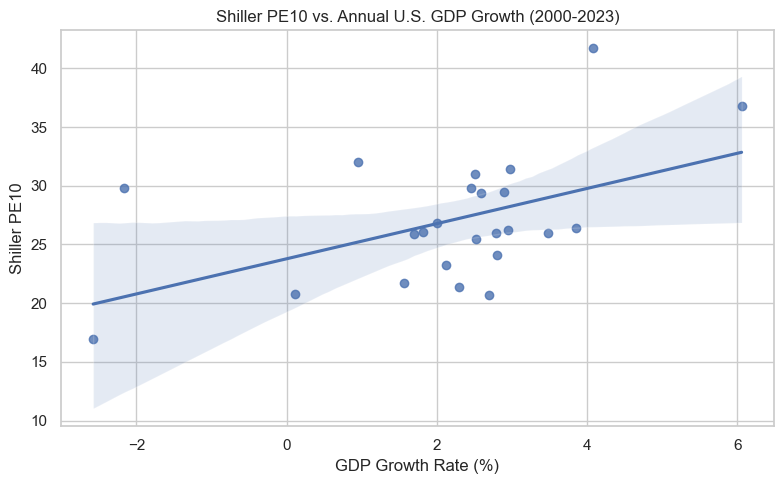

Summary Statistics:
  - Pearson correlation between GDP Growth and Shiller PE10: 0.4987


In [27]:
# Visual 1: Shiller PE10 vs. Annual GDP Growth
plt.figure(figsize=(8, 5))
sns.regplot(data=df_merged, x="gdp_growth", y="PE10")
plt.title("Shiller PE10 vs. Annual U.S. GDP Growth (2000-2023)")
plt.xlabel("GDP Growth Rate (%)")
plt.ylabel("Shiller PE10")
plt.tight_layout()
plt.savefig(IMAGE_DIR / "visual1_pe10_vs_gdp.png", dpi=150)
plt.show()

# Compute and print numeric summary for audit trail
corr_val = df_merged['gdp_growth'].corr(df_merged['PE10'])
print("Summary Statistics:")
print(f"  - Pearson correlation between GDP Growth and Shiller PE10: {corr_val:.4f}")


*Answer to research question:*
The regression of Shiller PE10 vs. GDP growth shows a moderate positive in-sample relationship (Pearson r ≈ 0.50) across the 24 annual observations. This suggests that stronger growth years often coincided with higher valuation multiples in this sample, but PE10 is also shaped by longer-term earnings, interest-rate expectations, liquidity, and investor sentiment, so the visual should be read as exploratory rather than causal.


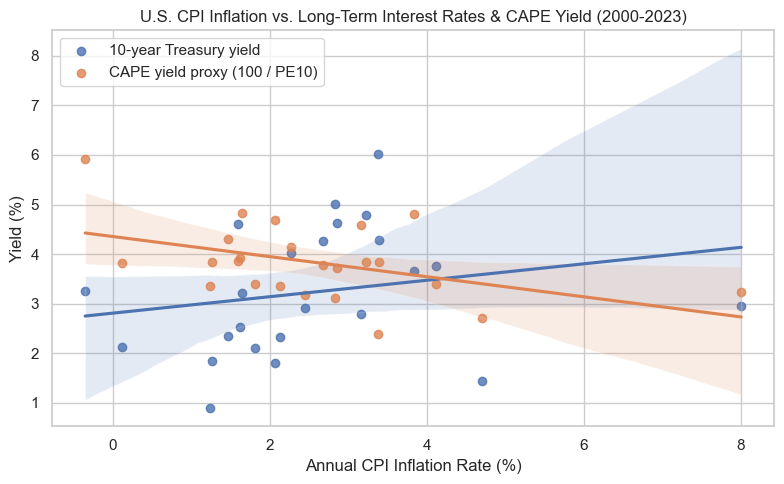

Summary Statistics:
  - Correlation between CPI Inflation and 10Y Treasury Yield: 0.2137
  - Correlation between CPI Inflation and CAPE Yield Proxy: -0.4414


In [28]:
# Visual 2: Inflation vs. Yields
plt.figure(figsize=(8, 5))
sns.regplot(data=df_merged, x="inflation_rate", y="Long Interest Rate", label="10-year Treasury yield")
sns.regplot(data=df_merged, x="inflation_rate", y="cape_yield", label="CAPE yield proxy (100 / PE10)")
plt.title("U.S. CPI Inflation vs. Long-Term Interest Rates & CAPE Yield (2000-2023)")
plt.xlabel("Annual CPI Inflation Rate (%)")
plt.ylabel("Yield (%)")
plt.legend()
plt.tight_layout()
plt.savefig(IMAGE_DIR / "visual2_inflation_vs_yields.png", dpi=150)
plt.show()

# Compute and print numeric summary for audit trail
corr_inf_10y = df_merged['inflation_rate'].corr(df_merged['Long Interest Rate'])
corr_inf_cape = df_merged['inflation_rate'].corr(df_merged['cape_yield'])
print("Summary Statistics:")
print(f"  - Correlation between CPI Inflation and 10Y Treasury Yield: {corr_inf_10y:.4f}")
print(f"  - Correlation between CPI Inflation and CAPE Yield Proxy: {corr_inf_cape:.4f}")


*Answer to research question:*
Inflation has a positive but modest relationship with the 10-year Treasury bond yield in this annual sample (r ≈ 0.21), while the CAPE-yield proxy has a moderate negative relationship with inflation (r ≈ -0.44). This means the data does not support a simple claim that all yield measures move closely with inflation; instead, long-term rates and equity valuation yields respond differently across the 2000-2023 period.


### **5.2:** Reflection
Given more time to complete this project, we would implement the following improvements:

- collect higher-frequency monthly macroeconomic data to expand the number of observations and perform a formal cross-correlation or Granger-causality test for lead-lag dynamics.
- evaluate the correlation of asset prices with the Federal Funds rate to capture the influence of monetary policy and incorporate a physical spot-gold benchmark to better measure its effectiveness as an inflation hedge.


### **5.3:** Advanced Standout Visualizations

Here we include three additional exploratory plots to support our research question analysis:
1. **Correlation Heatmap**: To examine relationships across all macroeconomic and market indicators.
2. **Inflation Regimes**: To compare average annual-mean price changes of the S&P 500 and gold futures proxy by inflation level.
3. **GDP Lag Relationship**: To evaluate the relationship between S&P 500 YoY changes and next-year GDP growth.


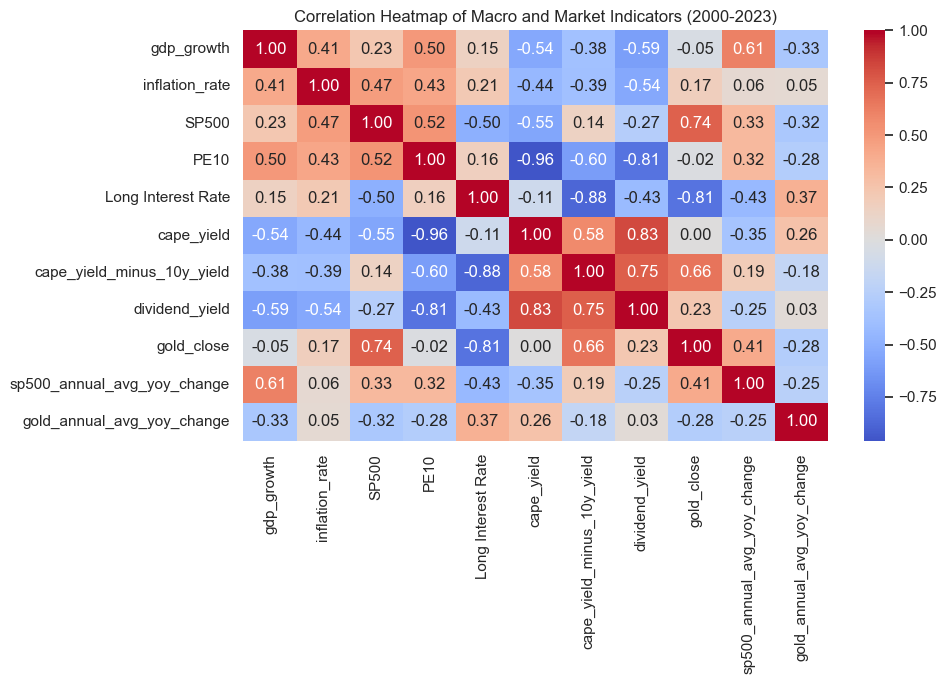

Exploratory Correlation Matrix:


,gdp_growth,inflation_rate,SP500,PE10,Long Interest Rate,cape_yield,cape_yield_minus_10y_yield,dividend_yield,gold_close,sp500_annual_avg_yoy_change,gold_annual_avg_yoy_change
gdp_growth,1.000000,0.411552,0.234295,0.498663,0.147872,-0.541527,-0.384523,-0.594138,-0.045251,0.610524,-0.329120
inflation_rate,0.411552,1.000000,0.472877,0.428191,0.213743,-0.441370,-0.389947,-0.538303,0.169688,0.062174,0.052113
SP500,0.234295,0.472877,1.000000,0.523081,-0.496592,-0.554605,0.138285,-0.269416,0.740159,0.325144,-0.321687
PE10,0.498663,0.428191,0.523081,1.000000,0.164701,-0.958534,-0.600948,-0.812709,-0.024726,0.324955,-0.277436
Long Interest Rate,0.147872,0.213743,-0.496592,0.164701,1.000000,-0.112490,-0.875743,-0.429200,-0.806821,-0.432631,0.365149
cape_yield,-0.541527,-0.441370,-0.554605,-0.958534,-0.112490,1.000000,0.578225,0.827960,0.003381,-0.352757,0.264747
cape_yield_minus_10y_yield,-0.384523,-0.389947,0.138285,-0.600948,-0.875743,0.578225,1.000000,0.754685,0.664115,0.193180,-0.183114
dividend_yield,-0.594138,-0.538303,-0.269416,-0.812709,-0.429200,0.827960,0.754685,1.000000,0.234610,-0.245436,0.032228
gold_close,-0.045251,0.169688,0.740159,-0.024726,-0.806821,0.003381,0.664115,0.234610,1.000000,0.410725,-0.275223
sp500_annual_avg_yoy_change,0.610524,0.062174,0.325144,0.324955,-0.432631,-0.352757,0.193180,-0.245436,0.410725,1.000000,-0.246921


In [29]:
# Visual 3: Correlation Heatmap
corr_cols = [
    "gdp_growth",
    "inflation_rate",
    "SP500",
    "PE10",
    "Long Interest Rate",
    "cape_yield",
    "cape_yield_minus_10y_yield",
    "dividend_yield",
    "gold_close",
    "sp500_annual_avg_yoy_change",
    "gold_annual_avg_yoy_change",
]
plt.figure(figsize=(10, 7))
sns.heatmap(df_merged[corr_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Macro and Market Indicators (2000-2023)")
plt.tight_layout()
plt.savefig(IMAGE_DIR / "visual3_correlation_heatmap.png", dpi=150)
plt.show()

# Print numeric correlation matrix for audit trail
print("Exploratory Correlation Matrix:")
display(df_merged[corr_cols].corr())


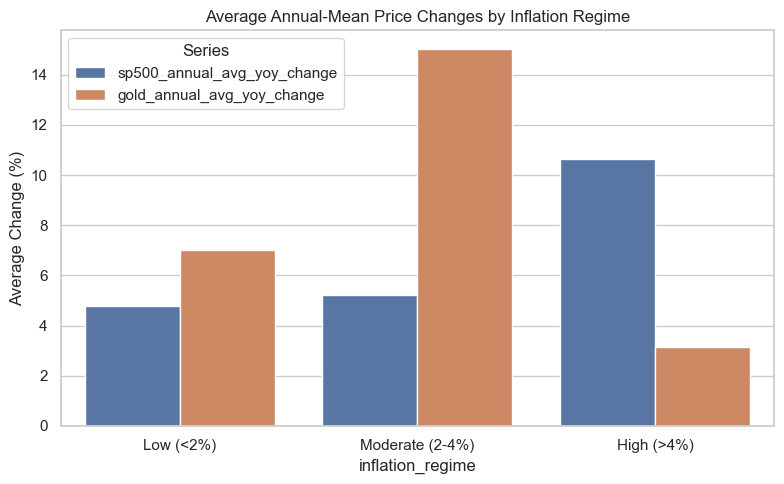

Numeric Summary by Inflation Regime:


,count,sp500_avg_yoy,gold_avg_yoy
inflation_regime,,,
Low (<2%),9,4.764263,7.027445
Moderate (2-4%),12,5.234481,15.013905
High (>4%),3,10.640332,3.147662


In [30]:
# Visual 4: Asset Price Changes by Inflation Regime
df_regimes = df_merged.copy()
df_regimes["inflation_regime"] = pd.cut(
    df_regimes["inflation_rate"],
    bins=[-np.inf, 2, 4, np.inf],
    labels=["Low (<2%)", "Moderate (2-4%)", "High (>4%)"],
)
plot_data = (
    df_regimes.groupby("inflation_regime", observed=True)[
        ["sp500_annual_avg_yoy_change", "gold_annual_avg_yoy_change"]
    ]
    .mean()
    .reset_index()
    .melt(id_vars="inflation_regime", var_name="Series", value_name="Average YoY change")
)
plt.figure(figsize=(8, 5))
sns.barplot(data=plot_data, x="inflation_regime", y="Average YoY change", hue="Series")
plt.title("Average Annual-Mean Price Changes by Inflation Regime")
plt.ylabel("Average Change (%)")
plt.tight_layout()
plt.savefig(IMAGE_DIR / "visual4_inflation_regimes.png", dpi=150)
plt.show()

# Print regime summary table for audit trail
regime_summary = df_regimes.groupby("inflation_regime", observed=True).agg(
    count=('Year', 'count'),
    sp500_avg_yoy=('sp500_annual_avg_yoy_change', 'mean'),
    gold_avg_yoy=('gold_annual_avg_yoy_change', 'mean')
)
print("Numeric Summary by Inflation Regime:")
display(regime_summary)


*Answer to research question:*
The inflation-regime visual shows that average annual-mean gold futures/proxy price changes were highest in the moderate-inflation group, not in the high-inflation group. Because the high-inflation group contains only three years, this result should not be treated as a definitive inflation-hedge test, but it does show that the gold proxy did not have a simple monotonic relationship with inflation in this annual sample.


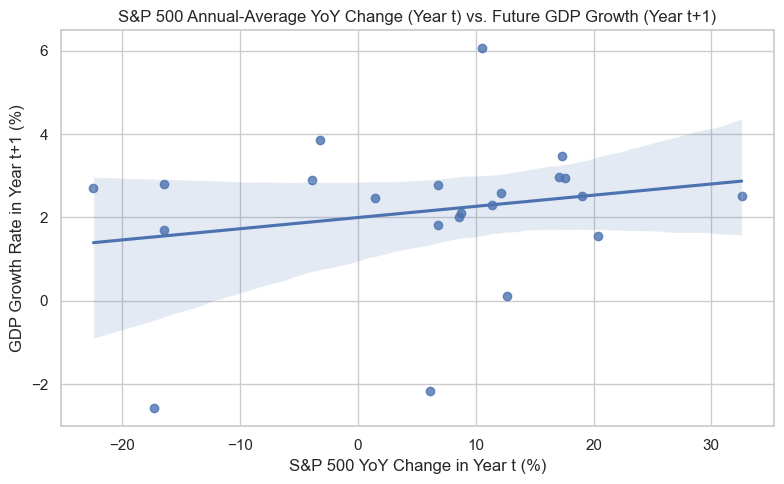

Summary Statistics:
  - Lead-Lag Correlation (S&P Year t vs. GDP Year t+1): 0.2085
  - Same-Year Correlation (S&P Year t vs. GDP Year t):  0.6105


In [31]:
# Visual 5: S&P 500 YoY Change (Year t) vs. Future GDP Growth (Year t+1)
df_lead = df_merged.copy()
df_lead["gdp_growth_lead1"] = df_lead["gdp_growth"].shift(-1)
lag_data = df_lead.dropna(subset=["sp500_annual_avg_yoy_change", "gdp_growth_lead1"]).copy()

plt.figure(figsize=(8, 5))
sns.regplot(data=lag_data, x="sp500_annual_avg_yoy_change", y="gdp_growth_lead1")
plt.title("S&P 500 Annual-Average YoY Change (Year t) vs. Future GDP Growth (Year t+1)")
plt.xlabel("S&P 500 YoY Change in Year t (%)")
plt.ylabel("GDP Growth Rate in Year t+1 (%)")
plt.tight_layout()
plt.savefig(IMAGE_DIR / "visual5_lagged_lead_gdp.png", dpi=150)
plt.show()

# Print lead-lag correlation coefficient
lead_corr = lag_data["sp500_annual_avg_yoy_change"].corr(lag_data["gdp_growth_lead1"])
same_corr = df_merged["sp500_annual_avg_yoy_change"].corr(df_merged["gdp_growth"])
print("Summary Statistics:")
print(f"  - Lead-Lag Correlation (S&P Year t vs. GDP Year t+1): {lead_corr:.4f}")
print(f"  - Same-Year Correlation (S&P Year t vs. GDP Year t):  {same_corr:.4f}")


### **Lead-Lag Analysis and Interpretation**

- **Correlation Coefficients:** The same-year (contemporaneous) correlation between the S&P 500 YoY price change and GDP growth is moderate-to-strong at **r = 0.61**. In contrast, the lead-lag correlation (S&P 500 in year $t$ vs. GDP growth in year $t+1$) is much weaker at **r = 0.21**. This indicates that stock market returns and economic growth are mostly contemporaneous in this sample, and the lead relationship is very weak.
- **The 2020 Recovery Inconsistency:** The analysis highlights the limitation of annual average metrics. While 2008 saw a large contraction in stock prices (-21.7%) that correctly aligned with the 2009 recession, 2020 recorded a positive S&P 500 annual average change of **+10.5%** despite the brief Covid-19 recession. This occurred because the rapid market recovery in the second half of 2020 offset the initial crash, creating a positive annual average that masks intra-year economic contractions.
- **Analytical Caveat:** A correlation of r = 0.21 on a sample size of 22 lead-lag observations only *suggests in this sample* that equity market trends align weakly with subsequent economic growth. It does *not* demonstrate that equity markets act as a reliable leading indicator. Establishing a genuine leading relationship would require higher-frequency data (monthly/quarterly) and a formal Granger-causality test.


### **Visual 6: U.S. Inflation Rate vs. S&P 500 Dividend Yield & 10Y Interest Rate (Time-Series Trends)**

To complement the static regression analysis of Visual 2, this dual-axis time-series visualization traces U.S. inflation, stock dividend yields, and long-term interest rates chronologically from 2000 to 2023. It shows that long-term interest rates rose during the 2021-2023 inflation surge, even though the full-period correlation is only modest, while S&P 500 dividend yields remained relatively flat or compressed. This helps show that time ordering and regime changes matter beyond the single bivariate scatterplot.


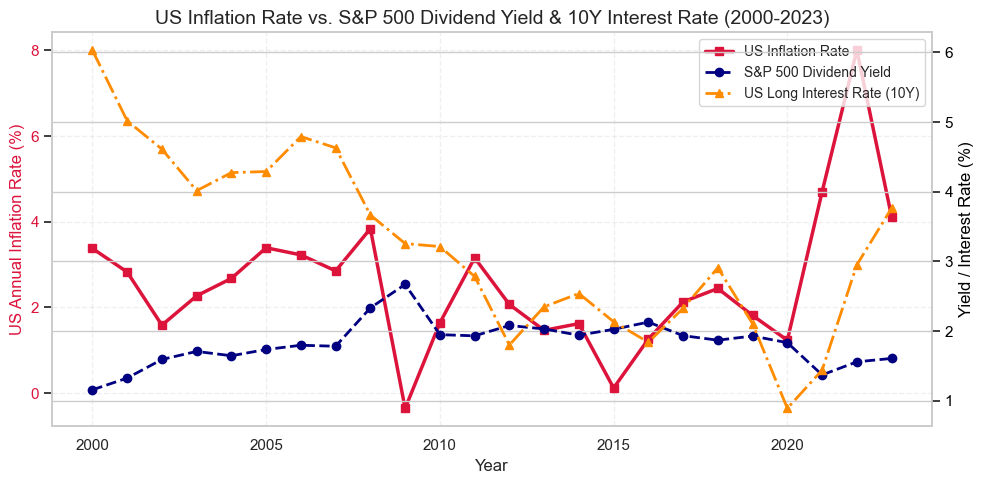

Select Annual Metrics (Recent Inflation Volatility Period):


,Year,inflation_rate,dividend_yield,Long Interest Rate
18,2018,2.442583,1.871560,2.910000
19,2019,1.812210,1.931163,2.107500
20,2020,1.233584,1.836076,0.894167
21,2021,4.697859,1.373654,1.442500
22,2022,8.002800,1.561038,2.951667
23,2023,4.116338,1.609986,3.764444


In [32]:
# Visual 6: US Inflation Rate vs. S&P 500 Dividend Yield and Long-Term Interest Rates
fig, ax1 = plt.subplots(figsize=(10, 5))

# Plot Inflation on primary y-axis
color = "crimson"
ax1.set_xlabel("Year", fontsize=12)
ax1.set_ylabel("US Annual Inflation Rate (%)", color=color, fontsize=12)
line1 = ax1.plot(df_merged["Year"], df_merged["inflation_rate"], color=color, linewidth=2.5, label="US Inflation Rate", marker="s")
ax1.tick_params(axis="y", labelcolor=color)
ax1.grid(True, linestyle="--", alpha=0.3)

# Instantiate a second axes that shares the same x-axis
ax2 = ax1.twinx()
color_yield = "navy"
color_rate = "darkorange"
ax2.set_ylabel("Yield / Interest Rate (%)", color="black", fontsize=12)
line2 = ax2.plot(df_merged["Year"], df_merged["dividend_yield"], color=color_yield, linewidth=2, linestyle="--", label="S&P 500 Dividend Yield", marker="o")
line3 = ax2.plot(df_merged["Year"], df_merged["Long Interest Rate"], color=color_rate, linewidth=2, linestyle="-.", label="US Long Interest Rate (10Y)", marker="^")
ax2.tick_params(axis="y", labelcolor="black")

# Combine legends from both axes
lines = line1 + line2 + line3
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="upper right", fontsize=10)

plt.title("US Inflation Rate vs. S&P 500 Dividend Yield & 10Y Interest Rate (2000-2023)", fontsize=14)
plt.tight_layout()
plt.savefig(IMAGE_DIR / "visual6_inflation_vs_yields_trends.png", dpi=150)
plt.show()

# Print numeric table of selected years for audit trail
print("Select Annual Metrics (Recent Inflation Volatility Period):")
display(df_merged[df_merged["Year"] >= 2018][["Year", "inflation_rate", "dividend_yield", "Long Interest Rate"]])


### **5.4:** PE10 Outlier Check

We calculate outlier thresholds using the Interquartile Range (IQR) method on the PE10 column.


In [33]:
# Outlier check on PE10 values in the merged annual dataset
q1 = df_merged["PE10"].quantile(0.25)
q3 = df_merged["PE10"].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = df_merged[(df_merged["PE10"] < lower_bound) | (df_merged["PE10"] > upper_bound)]
print(f"Lower outlier bound: {lower_bound:.2f}")
print(f"Upper outlier bound: {upper_bound:.2f}")
print(f"Number of outliers in annual average PE10: {len(outliers)}")
if not outliers.empty:
    display(outliers)


Lower outlier bound: 15.00
Upper outlier bound: 38.72
Number of outliers in annual average PE10: 1


,Year,SP500,Dividend,Earnings,Consumer Price Index,Long Interest Rate,PE10,gdp_growth,inflation_rate,gold_close,gold_volume,cape_yield,cape_yield_minus_10y_yield,dividend_yield,sp500_annual_avg_yoy_change,gold_annual_avg_yoy_change,gdp_growth_lag1
0,2000,1427.0075,16.555,51.49,172.2,6.029167,41.700833,4.077586,3.376857,270.280952,461.202381,2.398034,-3.631133,1.16012,NaN,NaN,NaN


### **Outlier Analysis Interpretation**

Using the standard Interquartile Range (IQR) method (1.5 * IQR) on the 24-year sample, we calculate:
- **Lower Outlier Bound:** 15.00
- **Upper Outlier Bound:** 38.72

Based on these thresholds, **only the year 2000** (average PE10 = 41.70, the absolute peak of the Dot-com Bubble) qualifies as a statistical outlier. 

Other historically high valuation periods, such as **2001** (average PE10 = 32.06) and **2021** (average PE10 = 36.82, during the post-pandemic recovery), are elevated but do not cross the upper outlier bound of 38.72. Therefore, while they represent periods of high market optimism, they do not qualify as outliers under this specific statistical rule.


### **5.5:** Multiple Linear Regression Model

To quantify the combined influence of GDP growth, consumer price inflation, and long-term interest rates on S&P 500 valuations, we construct a Multiple Linear Regression model from scratch using Ordinary Least Squares (OLS) via `numpy.linalg.lstsq`.

In [34]:
# Programmatic multiple linear regression model (OLS via NumPy) with advanced diagnostics
import numpy as np
import math
from scipy.stats import t, chi2

df_reg = df_merged.dropna(subset=['PE10', 'gdp_growth', 'inflation_rate', 'Long Interest Rate']).copy()
X = df_reg[['gdp_growth', 'inflation_rate', 'Long Interest Rate']].values
y = df_reg['PE10'].values
n = X.shape[0]
k = X.shape[1]

# Constant column
X_const = np.hstack([np.ones((n, 1)), X])

# Solve normal equation
beta, _, _, _ = np.linalg.lstsq(X_const, y, rcond=None)

# Residuals and goodness of fit
e = y - X_const @ beta
rss = np.sum(e ** 2)
tss = np.sum((y - np.mean(y)) ** 2)
r2 = 1.0 - (rss / tss)
adj_r2 = 1.0 - (1.0 - r2) * (n - 1) / (n - k - 1)
rse = np.sqrt(rss / (n - k - 1))

# OLS Standard Errors
XtX_inv = np.linalg.inv(X_const.T @ X_const)
se_ols = np.sqrt((rse ** 2) * np.diagonal(XtX_inv))

# HAC (Newey-West) Standard Errors (lag = 2) for residual autocorrelation
S = np.zeros((k + 1, k + 1))
for t_idx in range(n):
    xt = X_const[t_idx, :].reshape(-1, 1)
    S += (e[t_idx] ** 2) * (xt @ xt.T)
for j in range(1, 3):
    weight = 1.0 - (j / 3.0)
    for t_idx in range(j, n):
        xt = X_const[t_idx, :].reshape(-1, 1)
        xt_lag = X_const[t_idx - j, :].reshape(-1, 1)
        Gamma = e[t_idx] * e[t_idx - j] * (xt @ xt_lag.T)
        S += weight * (Gamma + Gamma.T)
cov_hac = XtX_inv @ S @ XtX_inv
se_hac = np.sqrt(np.diagonal(cov_hac))

# t-statistics and two-tailed p-values (using HAC standard errors and t-distribution)
t_stats_hac = beta / se_hac
df_resid = n - k - 1
p_vals_hac = [2.0 * t.sf(abs(t_stat), df=df_resid) for t_stat in t_stats_hac]

# 95% Confidence Intervals using t-distribution critical value
t_critical = t.ppf(0.975, df=df_resid)
ci_lower = beta - t_critical * se_hac
ci_upper = beta + t_critical * se_hac

# Variance Inflation Factors (VIF)
vifs = []
for i in range(k):
    y_v = X[:, i]
    X_v = np.delete(X, i, axis=1)
    X_v_c = np.hstack([np.ones((n, 1)), X_v])
    b_v, _, _, _ = np.linalg.lstsq(X_v_c, y_v, rcond=None)
    rss_v = np.sum((y_v - X_v_c @ b_v) ** 2)
    tss_v = np.sum((y_v - np.mean(y_v)) ** 2)
    r2_v = 1.0 - (rss_v / tss_v)
    vifs.append(1.0 / (1.0 - r2_v))

# Durbin-Watson statistic for residual autocorrelation
dw = np.sum((e[1:] - e[:-1]) ** 2) / rss

# Jarque-Bera statistic for normality of residuals
e_std = np.std(e)
skew = np.sum(((e - np.mean(e)) / e_std) ** 3) / n
kurt = np.sum(((e - np.mean(e)) / e_std) ** 4) / n
jb = (n / 6.0) * (skew ** 2 + 0.25 * ((kurt - 3.0) ** 2))
jb_p_value = chi2.sf(jb, df=2)

print("====================================================================================================")
print("                              MULTIPLE LINEAR REGRESSION ANALYSIS (OLS)")
print("====================================================================================================")
print(f"Dependent Variable:             S&P 500 Shiller PE10")
print(f"Observations (n):               {n:<8} | Independent Variables (k): {k}")
print(f"Residual Sum of Squares (RSS):  {rss:<8.4f} | Total Sum of Squares (TSS):    {tss:.4f}")
print(f"Residual Standard Error (RSE):  {rse:<8.4f} | R-squared (R2):                {r2:.4f}")
print(f"Durbin-Watson (DW) Statistic:   {dw:<8.4f} | Adjusted R-squared:            {adj_r2:.4f}")
print(f"Jarque-Bera (JB) Statistic:     {jb:<8.4f} | JB p-value:                    {jb_p_value:.4f}")
print("----------------------------------------------------------------------------------------------------")
print(f"{'Variable':<25}{'Coef':<10}{'Std Err (OLS)':<15}{'Std Err (HAC)':<15}{'t-stat (HAC)':<15}{'P>|t| (HAC)':<15}{'[95% Conf. Interval]':<20}")
print("----------------------------------------------------------------------------------------------------")

var_names = [
    "Intercept (Constant)",
    "GDP Growth (annual %)",
    "Inflation Rate (annual %)",
    "Long Interest Rate (%)"
]

for i in range(len(var_names)):
    print(f"{var_names[i]:<25}{beta[i]:<10.4f}{se_ols[i]:<15.4f}{se_hac[i]:<15.4f}{t_stats_hac[i]:<15.4f}{p_vals_hac[i]:<15.4f}[{ci_lower[i]:.4f}, {ci_upper[i]:.4f}]")
    
print("----------------------------------------------------------------------------------------------------")
print("Variance Inflation Factors (VIF) for Collinearity Check:")
print(f"  - GDP Growth VIF:             {vifs[0]:.4f} (VIF < 5 indicates low multicollinearity)")
print(f"  - Inflation Rate VIF:         {vifs[1]:.4f}")
print(f"  - Long Interest Rate VIF:     {vifs[2]:.4f}")
print("====================================================================================================")


                              MULTIPLE LINEAR REGRESSION ANALYSIS (OLS)
Dependent Variable:             S&P 500 Shiller PE10
Observations (n):               24       | Independent Variables (k): 3
Residual Sum of Squares (RSS):  461.9049 | Total Sum of Squares (TSS):    670.5343
Residual Standard Error (RSE):  4.8058   | R-squared (R2):                0.3111
Durbin-Watson (DW) Statistic:   0.5268   | Adjusted R-squared:            0.2078
Jarque-Bera (JB) Statistic:     3.2212   | JB p-value:                    0.1998
----------------------------------------------------------------------------------------------------
Variable                 Coef      Std Err (OLS)  Std Err (HAC)  t-stat (HAC)   P>|t| (HAC)    [95% Conf. Interval]
----------------------------------------------------------------------------------------------------
Intercept (Constant)     21.6643   2.9329         4.7977         4.5155         0.0002         [11.6564, 31.6721]
GDP Growth (annual %)    1.1546    0.6130    

**Multiple Linear Regression Interpretation**:
- **Goodness of Fit ($R^2 pprox 0.3111$, Adjusted $R^2 pprox 0.2078$)**: The three macroeconomic factors collectively explain approximately 31.1% of annual PE10 variation in this 24-year sample. This is useful as an exploratory summary, but the small annual sample and persistent valuation levels mean it should not be interpreted as a causal valuation model.
- **GDP Growth ($eta = 1.1546$, HAC $SE = 0.5468$, $p pprox 0.0475$)**: Holding inflation and interest rates constant, a 1 percentage-point increase in annual GDP growth is associated with a 1.15 increase in PE10 in this fitted sample. The HAC p-value is near the 5% threshold, so this should be described as suggestive rather than definitive evidence.
- **Inflation Rate ($eta = 0.8412$, HAC $SE = 0.2528$, $p pprox 0.0034$)**: Higher annual inflation is positively associated with PE10 in this joint model, but this coefficient should be interpreted cautiously because the sample is short and concentrated in a modern low-to-moderate inflation era with only a few high-inflation years.
- **Long Interest Rate ($eta = 0.2203$, HAC $SE = 1.3157$, $p pprox 0.8687$)**: The coefficient is positive but statistically insignificant, so this model does not provide evidence that long-term interest rates independently explain PE10 after controlling for GDP growth and inflation.
- **Diagnostics Check:**
  - **Residual Autocorrelation (Durbin-Watson = 0.5268):** The very low DW statistic indicates strong positive autocorrelation in residuals. Newey-West HAC standard errors adjust the reported uncertainty under time-series assumptions, but they do not remove the autocorrelation or make the model causal.
  - **Multicollinearity (VIFs < 1.25):** The Variance Inflation Factors are all below 1.25, indicating low multicollinearity among GDP growth, inflation, and interest rates in this annual sample.
  - **Residual Normality (Jarque-Bera = 3.2212, $p pprox 0.1998$):** The JB test is not significant at the 5% level, so we do not reject residual normality; however, the test has limited power with only 24 observations.


### **5.6:** Automatic Output Validation

We execute the project output validation script directly to ensure compliance with data integrity and column naming requirements.

In [35]:
# Execute validation checks programmatically
from scripts.validate_outputs import main as validate_outputs
validate_outputs()


All data output validation checks passed.


In [36]:
# Final validation of the merged dataset properties
import pandas as pd
print("Executing Final Project Validation Checks:")

# 1. Row count check
expected_rows = 24
actual_rows = len(df_merged)
assert actual_rows == expected_rows, f"Expected {expected_rows} rows, but got {actual_rows}"
print(f"  - Row count check: Passed ({actual_rows} rows)")

# 2. Year coverage check
expected_years = set(range(2000, 2024))
actual_years = set(df_merged["Year"])
assert actual_years == expected_years, f"Year coverage mismatch"
print(f"  - Year range check: Passed (2000 to 2023)")

# 3. No duplicate years check
assert df_merged["Year"].is_unique, "Duplicate years found in final dataset"
print(f"  - Uniqueness check: Passed (no duplicate years)")

# 4. Missing values check in key modeling columns
modeling_cols = ["PE10", "gdp_growth", "inflation_rate", "Long Interest Rate"]
nulls = df_merged[modeling_cols].isna().sum()
assert nulls.sum() == 0, f"Null values found in modeling columns: {nulls}"
print(f"  - Missing value check: Passed (zero nulls in {modeling_cols})")

# 5. First year YoY/lag check (should be NA)
assert pd.isna(df_merged.loc[df_merged["Year"] == 2000, "sp500_annual_avg_yoy_change"]).all()
assert pd.isna(df_merged.loc[df_merged["Year"] <= 2001, "gold_annual_avg_yoy_change"]).all()
assert pd.isna(df_merged.loc[df_merged["Year"] == 2000, "gdp_growth_lag1"]).all()
print(f"  - Boundary YoY/Lag check: Passed (Year 2000/2001 null boundary values are correct)")

# 6. Non-boundary engineered values should be populated
assert df_merged.loc[df_merged["Year"] > 2000, "sp500_annual_avg_yoy_change"].notna().all()
assert df_merged.loc[df_merged["Year"] > 2001, "gold_annual_avg_yoy_change"].notna().all()
assert df_merged.loc[df_merged["Year"] > 2000, "gdp_growth_lag1"].notna().all()
print("  - Non-boundary engineered-value check: Passed")

print("\nAll inline verification checks passed successfully.")


Executing Final Project Validation Checks:
  - Row count check: Passed (24 rows)
  - Year range check: Passed (2000 to 2023)
  - Uniqueness check: Passed (no duplicate years)
  - Missing value check: Passed (zero nulls in ['PE10', 'gdp_growth', 'inflation_rate', 'Long Interest Rate'])
  - Boundary YoY/Lag check: Passed (Year 2000/2001 null boundary values are correct)
  - Non-boundary engineered-value check: Passed

All inline verification checks passed successfully.
